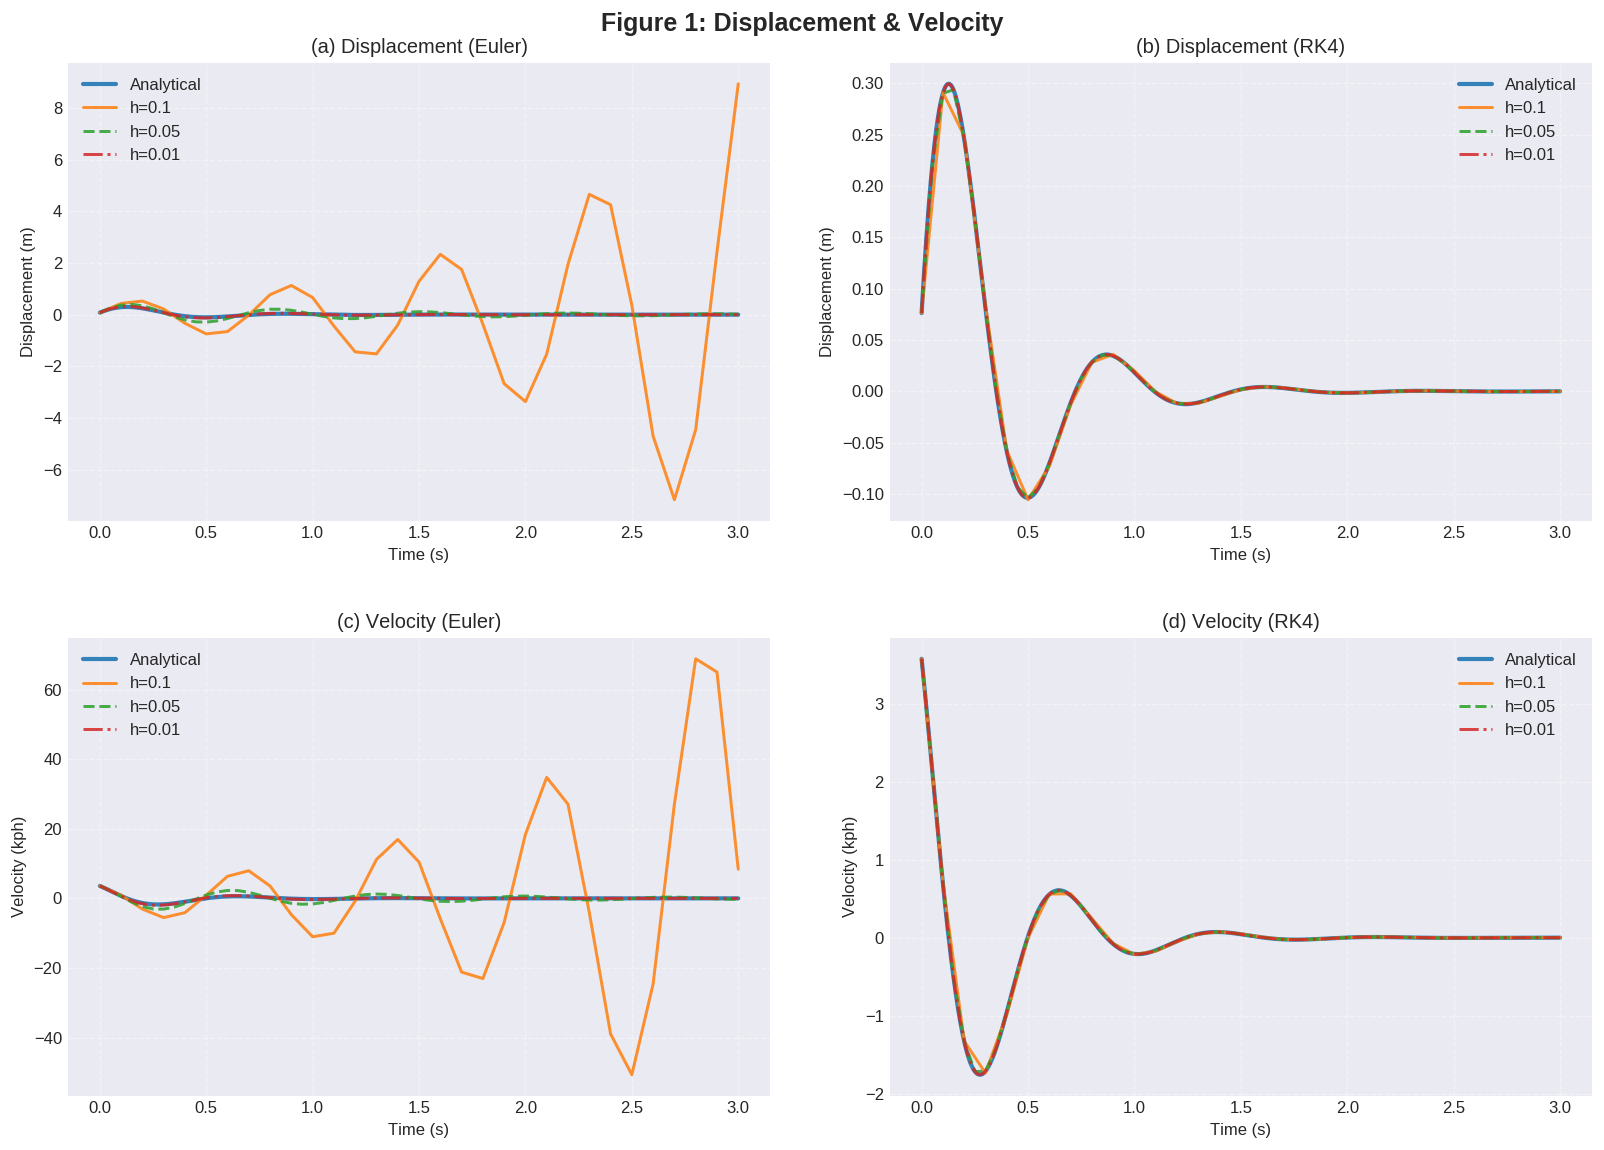

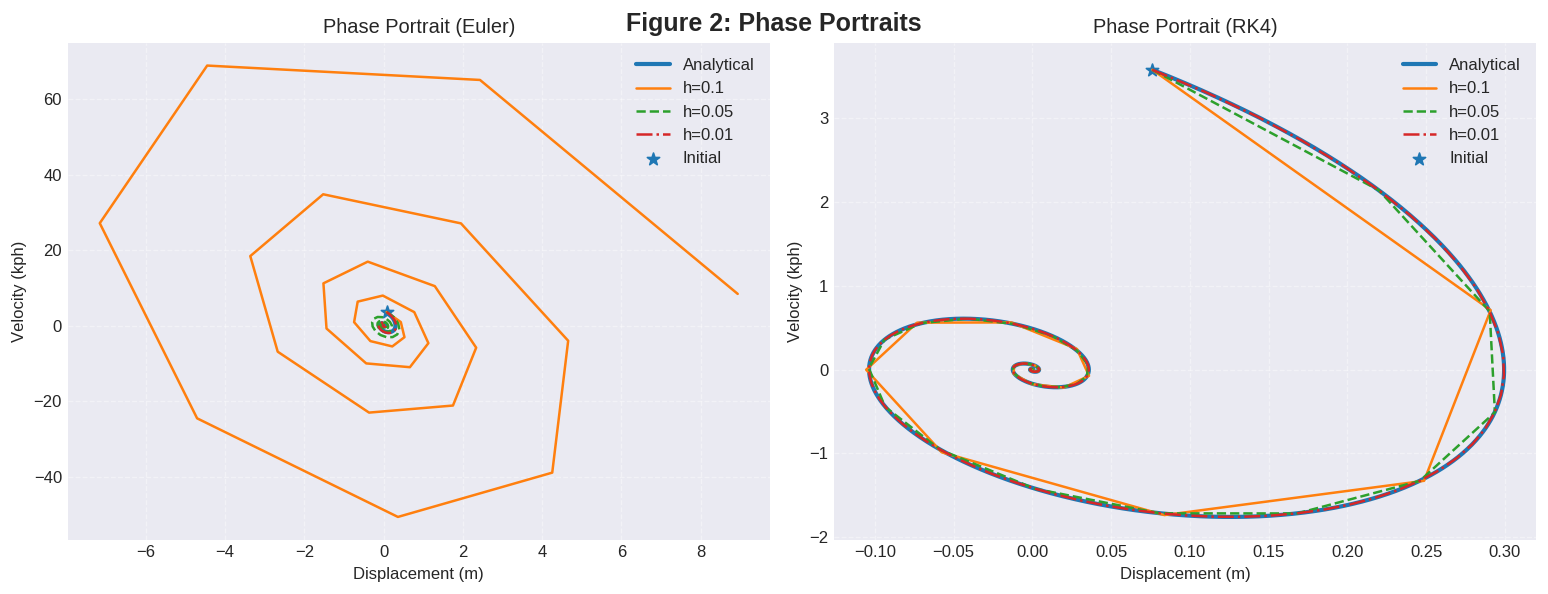

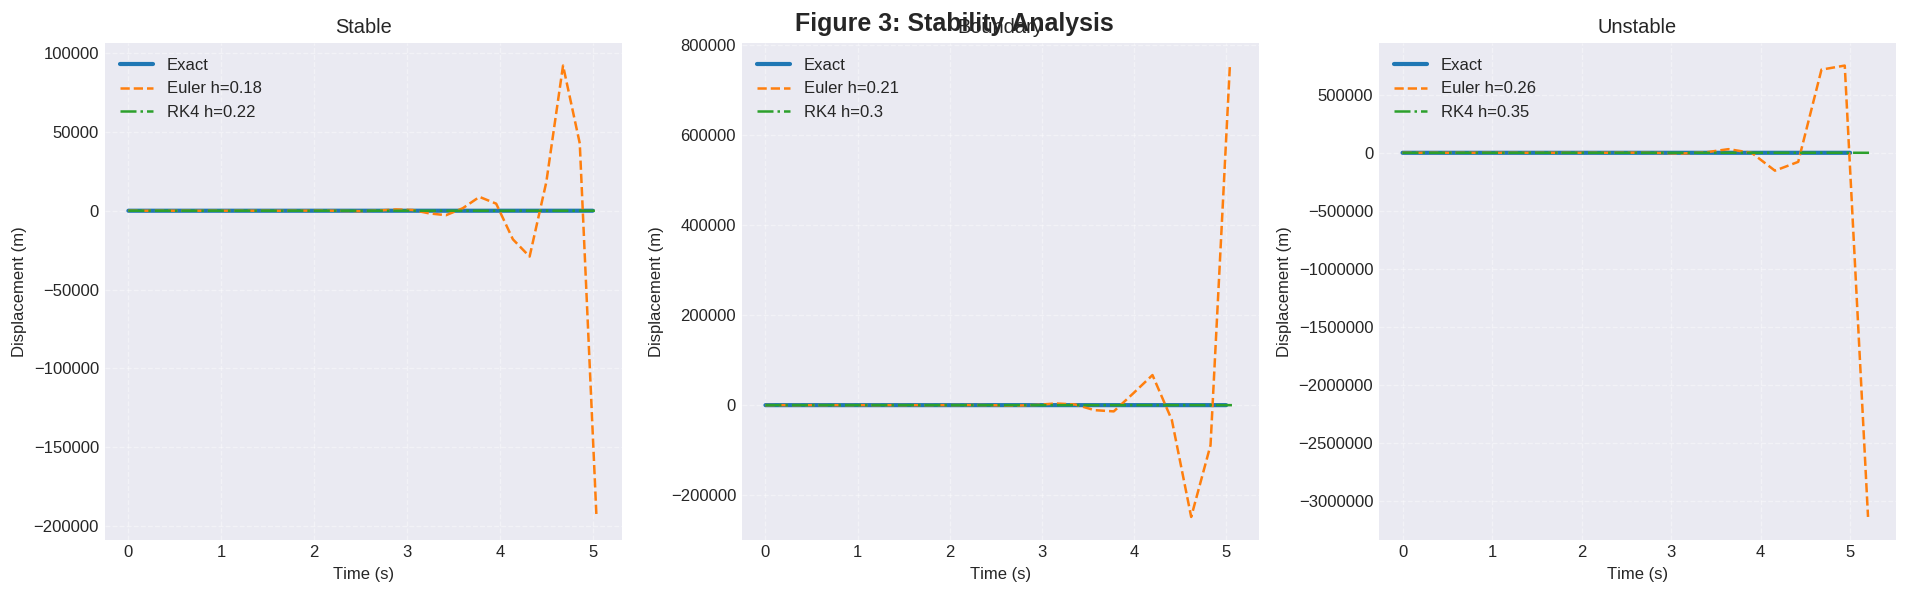

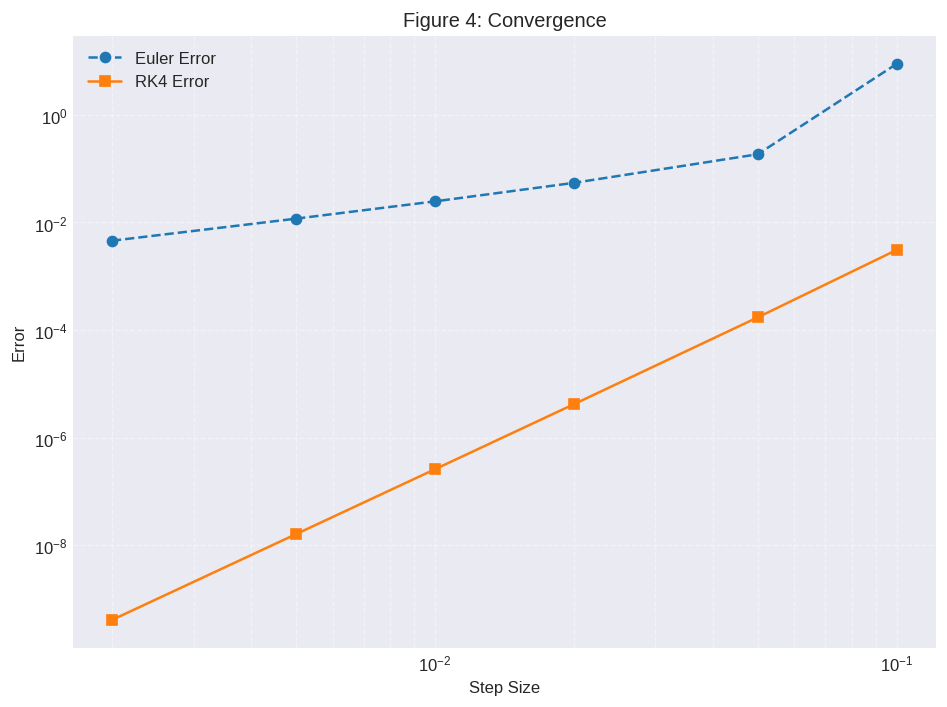

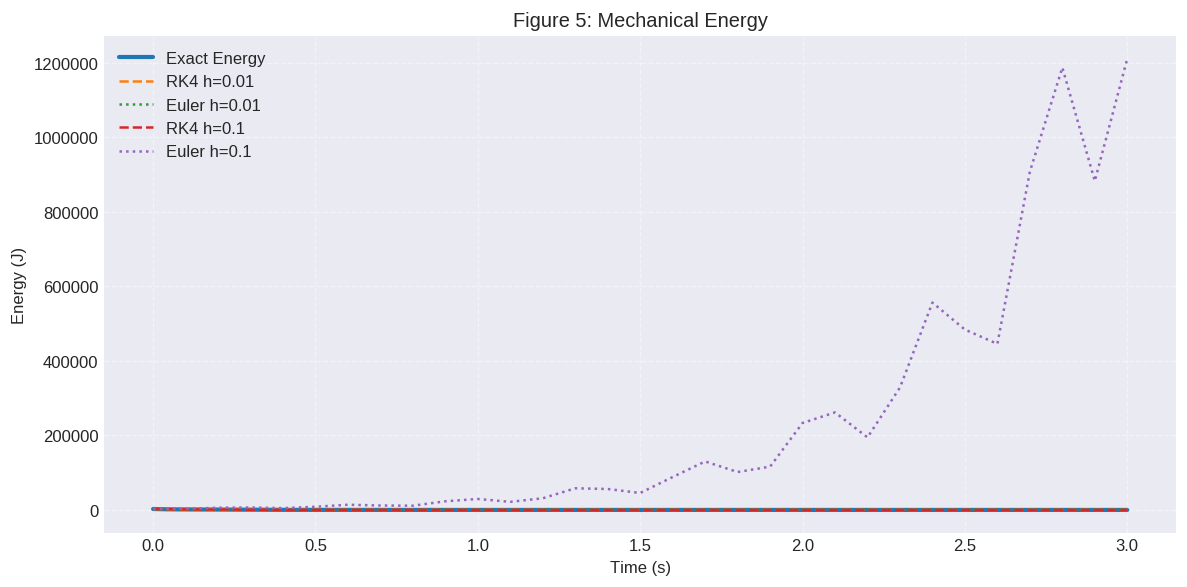

In [3]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-darkgrid")

mass = 375.35
spring_k = 30000.0
damping_ratio = 0.32

y_init = 0.0762
v_init = 3.58
t_final = 3.0

omega_n = np.sqrt(spring_k / mass)
omega_d = omega_n * np.sqrt(1 - damping_ratio**2)
c = 2 * damping_ratio * np.sqrt(mass * spring_k)

def smd_ode(t, y, v, m, c, k):
    dy_dt = v
    dv_dt = -(c / m) * v - (k / m) * y
    return dy_dt, dv_dt

def euler_step(func, y0, v0, t0, tf, h, m, c, k):
    t_vals = np.arange(t0, tf + h, h)
    n = len(t_vals)

    y_vals = np.zeros(n)
    v_vals = np.zeros(n)

    y_vals[0] = y0
    v_vals[0] = v0

    for i in range(n - 1):
        dy, dv = func(t_vals[i], y_vals[i], v_vals[i], m, c, k)
        y_vals[i + 1] = y_vals[i] + h * dy
        v_vals[i + 1] = v_vals[i] + h * dv

    return t_vals, y_vals, v_vals

def rk4_step(func, y0, v0, t0, tf, h, m, c, k):
    t_vals = np.arange(t0, tf + h, h)
    n = len(t_vals)

    y_vals = np.zeros(n)
    v_vals = np.zeros(n)

    y_vals[0] = y0
    v_vals[0] = v0

    for i in range(n - 1):
        t = t_vals[i]
        y = y_vals[i]
        v = v_vals[i]

        k1_y, k1_v = func(t, y, v, m, c, k)
        k2_y, k2_v = func(t + h/2, y + h/2*k1_y, v + h/2*k1_v, m, c, k)
        k3_y, k3_v = func(t + h/2, y + h/2*k2_y, v + h/2*k2_v, m, c, k)
        k4_y, k4_v = func(t + h, y + h*k3_y, v + h*k3_v, m, c, k)

        y_vals[i + 1] = y + (h/6)*(k1_y + 2*k2_y + 2*k3_y + k4_y)
        v_vals[i + 1] = v + (h/6)*(k1_v + 2*k2_v + 2*k3_v + k4_v)

    return t_vals, y_vals, v_vals

def exact_sol(t, y0, v0, omega_n, zeta, omega_d):
    A = y0
    B = (v0 + zeta * omega_n * y0) / omega_d

    return np.exp(-zeta * omega_n * t) * (
        A * np.cos(omega_d * t) + B * np.sin(omega_d * t)
    )

step_sizes = [0.1, 0.05, 0.01]

t_exact = np.linspace(0, t_final, 5000)
y_exact = exact_sol(t_exact, y_init, v_init, omega_n, damping_ratio, omega_d)

A = y_init
B = (v_init + damping_ratio * omega_n * y_init) / omega_d

v_exact = np.exp(-damping_ratio * omega_n * t_exact) * (
    (-damping_ratio * omega_n) * (A * np.cos(omega_d * t_exact) + B * np.sin(omega_d * t_exact))
    + omega_d * (-A * np.sin(omega_d * t_exact) + B * np.cos(omega_d * t_exact))
)

euler_data = {}
rk4_data = {}

for h in step_sizes:
    euler_data[h] = euler_step(smd_ode, y_init, v_init, 0, t_final, h, mass, c, spring_k)
    rk4_data[h] = rk4_step(smd_ode, y_init, v_init, 0, t_final, h, mass, c, spring_k)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=120)
fig.suptitle("Figure 1: Displacement & Velocity", fontsize=15, fontweight='bold')

linestyles = ['-', '--', '-.', ':']

plots = [
    (axes[0,0], euler_data, "(a) Displacement (Euler)", 'y', 'Displacement (m)'),
    (axes[0,1], rk4_data,   "(b) Displacement (RK4)",   'y', 'Displacement (m)'),
    (axes[1,0], euler_data, "(c) Velocity (Euler)",     'v', 'Velocity (kph)'),
    (axes[1,1], rk4_data,   "(d) Velocity (RK4)",       'v', 'Velocity (kph)')
]

for ax, data, title, mode, label in plots:
    ref = y_exact if mode == 'y' else v_exact

    ax.plot(t_exact, ref, linewidth=2.5, alpha=0.9, label="Analytical")

    for i, h in enumerate(step_sizes):
        t_vals, y_vals, v_vals = data[h]
        ax.plot(
            t_vals,
            y_vals if mode == 'y' else v_vals,
            linestyle=linestyles[i],
            linewidth=1.8,
            alpha=0.85,
            label=f"h={h}"
        )

    ax.set_title(title)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel(label)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout(pad=3.0)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=120)
fig.suptitle("Figure 2: Phase Portraits", fontsize=15, fontweight='bold')

for ax, data, name in [
    (axes[0], euler_data, "Euler"),
    (axes[1], rk4_data, "RK4")
]:
    ax.plot(y_exact, v_exact, linewidth=2.5, label="Analytical")

    for i, h in enumerate(step_sizes):
        t_vals, y_vals, v_vals = data[h]
        ax.plot(y_vals, v_vals, linestyle=linestyles[i], label=f"h={h}")

    ax.scatter([y_init], [v_init], s=60, marker='*', label="Initial")
    ax.set_title(f"Phase Portrait ({name})")
    ax.set_xlabel("Displacement (m)")
    ax.set_ylabel("Velocity (kph)")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

t_stable = 5.0
t_ex = np.linspace(0, t_stable, 8000)
y_ex = exact_sol(t_ex, y_init, v_init, omega_n, damping_ratio, omega_d)

scenarios = [
    (0.18, 0.22, "Stable"),
    (0.21, 0.30, "Boundary"),
    (0.26, 0.35, "Unstable"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=120)
fig.suptitle("Figure 3: Stability Analysis", fontsize=15, fontweight='bold')

for ax, (h1, h2, title) in zip(axes, scenarios):
    t1, y1, _ = euler_step(smd_ode, y_init, v_init, 0, t_stable, h1, mass, c, spring_k)
    t2, y2, _ = rk4_step(smd_ode, y_init, v_init, 0, t_stable, h2, mass, c, spring_k)

    ax.plot(t_ex, y_ex, linewidth=2.5, label="Exact")
    ax.plot(t1, y1, linestyle='--', label=f"Euler h={h1}")
    ax.plot(t2, y2, linestyle='-.', label=f"RK4 h={h2}")

    ax.set_title(title)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Displacement (m)")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

h_vals = np.array([0.1, 0.05, 0.02, 0.01, 0.005, 0.002])

err_euler = []
err_rk4 = []

for h in h_vals:
    t1, y1, _ = euler_step(smd_ode, y_init, v_init, 0, t_final, h, mass, c, spring_k)
    t2, y2, _ = rk4_step(smd_ode, y_init, v_init, 0, t_final, h, mass, c, spring_k)

    err_euler.append(np.max(np.abs(y1 - exact_sol(t1, y_init, v_init, omega_n, damping_ratio, omega_d))))
    err_rk4.append(np.max(np.abs(y2 - exact_sol(t2, y_init, v_init, omega_n, damping_ratio, omega_d))))

fig, ax = plt.subplots(figsize=(8, 6), dpi=120)

ax.loglog(h_vals, err_euler, marker='o', linestyle='--', label="Euler Error")
ax.loglog(h_vals, err_rk4, marker='s', linestyle='-', label="RK4 Error")

ax.set_title("Figure 4: Convergence")
ax.set_xlabel("Step Size")
ax.set_ylabel("Error")
ax.legend()
ax.grid(True, which="both", linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5), dpi=120)

E_exact = 0.5 * mass * v_exact**2 + 0.5 * spring_k * y_exact**2
ax.plot(t_exact, E_exact, linewidth=2.5, label="Exact Energy")

for h in [0.01, 0.1]:
    t1, y1, v1 = rk4_data[h]
    ax.plot(t1, 0.5*mass*v1**2 + 0.5*spring_k*y1**2, linestyle='--', label=f"RK4 h={h}")

    t2, y2, v2 = euler_data[h]
    ax.plot(t2, 0.5*mass*v2**2 + 0.5*spring_k*y2**2, linestyle=':', label=f"Euler h={h}")

ax.set_title("Figure 5: Mechanical Energy")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Energy (J)")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()